# Heston stochastic volatility model

## Model presentation

1. Under the Heston stochastic volatility model we have the following SDE under $\mathbb{Q}$ <br><br>
$$
 \begin{align}
dS_t &= rS_tdt +\sqrt{v_t} S_tdW_s^{\mathbb{Q}} \\
dv_t &= \kappa (\zeta - v_t)dt + \gamma\sqrt{v_t}dW_v^{\mathbb{Q}} \\
\end{align}
$$<br>
with correlation between the brownian motions $\rho_{s,v}$

1. The variance follows a CIR process 

1. now consider the value of a derivative. using the fundamental theorm of asset pricing we have
$$V(t, S_t, v_t) = M(t) \mathbb{E^Q}\left [  \dfrac{1}{M(T)} V(T,S,v)  \right]$$

1. we know that $\dfrac{V(t,S,v)}{M(t)}$ is a martingale under $\mathbb{Q}$ hence should have no drift

1. We apply the Ito lemma and see the results and set the drift to 0 to find the Heston stochastic PDE <br><br>
$$V_t + rSV_s + \kappa (\zeta - v) V_v + \dfrac{1}{2}vS^2V_{ss} + \rho_{s,v}\gamma S v V_{s,v} + \dfrac{1}{2}v\gamma^2V_{vv} - rV=0$$

1. The characteristic function is given as 
$$\phi(u;t,T) = exp\left( A(u,\tau) + B(u,\tau)X_t + C(u,\tau) v_t  \right)$$ <br>
where <br>
$
 \begin{align}
A(u,\tau) &= r (iu -1)\tau + \dfrac{k\zeta\tau}{\gamma^2 }(\kappa -\gamma \rho_{s,v}iu - D_1) - \dfrac{2\kappa\zeta}{\gamma^2}\text{log}\left( \dfrac{1 - ge^{-D_1\tau}}{1-g} \right), & 
D_1 &= \sqrt{(\kappa - \gamma \rho_{s,v}iu)^2   + (u^2 +iu )\gamma^2} \\
B(u, \tau) &= iu , & g &= \dfrac{k-\gamma\rho_{s,v} i u - D_1}{k-\gamma\rho_{s,v} i u + D_1}\\
C(u,\tau)  &= \dfrac{1 - e^{-D_1\tau}}{\gamma^2 \left( 1 - g e^{-D_1\tau} \right)} (\kappa - \gamma \rho_{s,v}iu -D_1), & \tau &= T- t
\end{align}
$
<br><br>
1. With the heston model we can fit several form of the implied volatility for example when longterm vol is 10%<br><br>
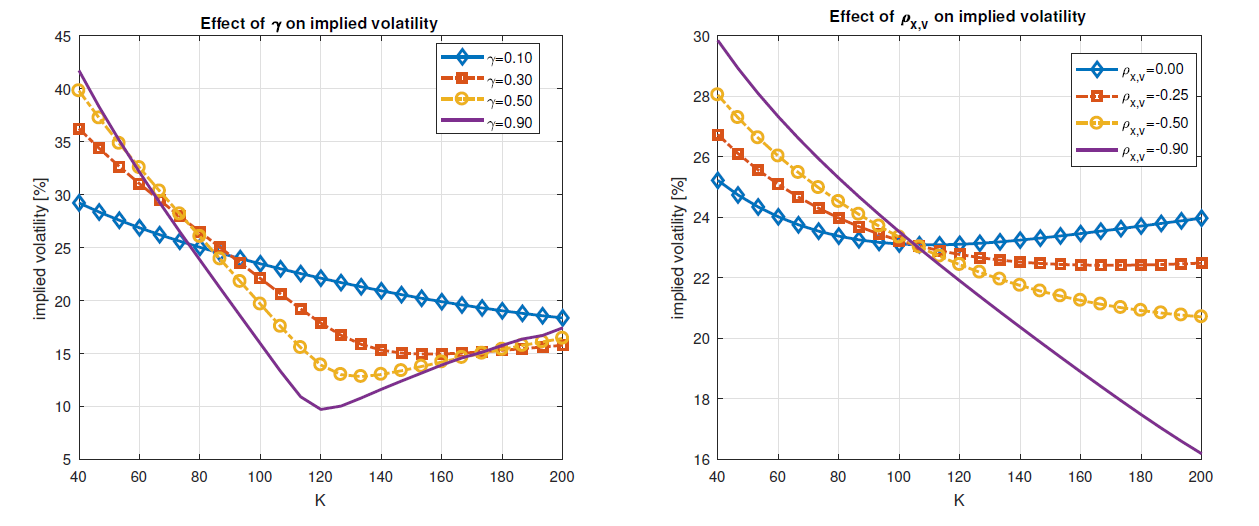<br>
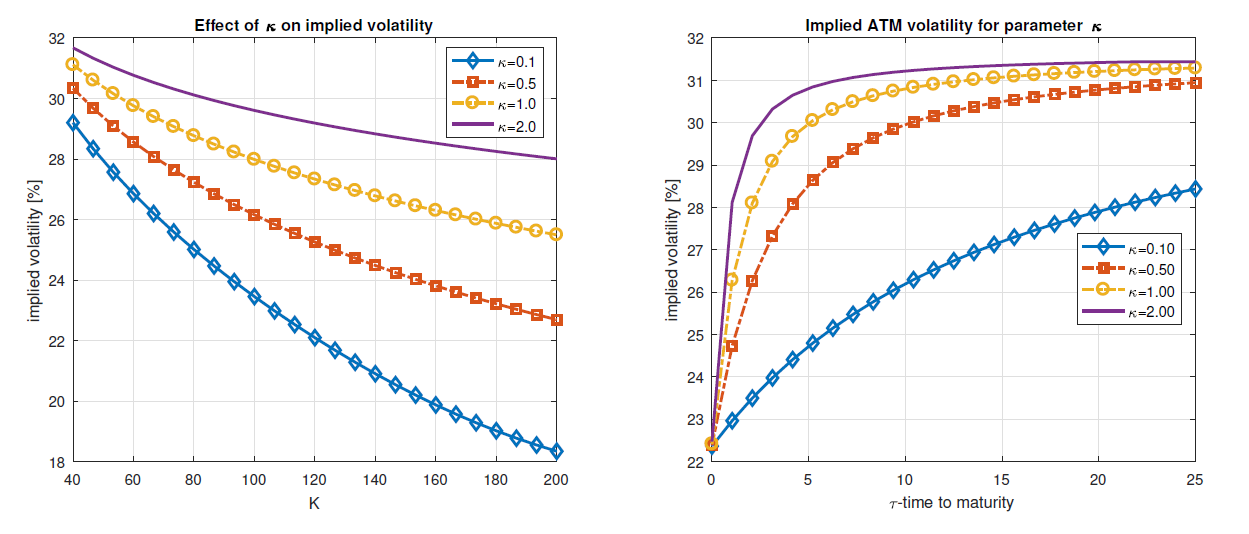<br>
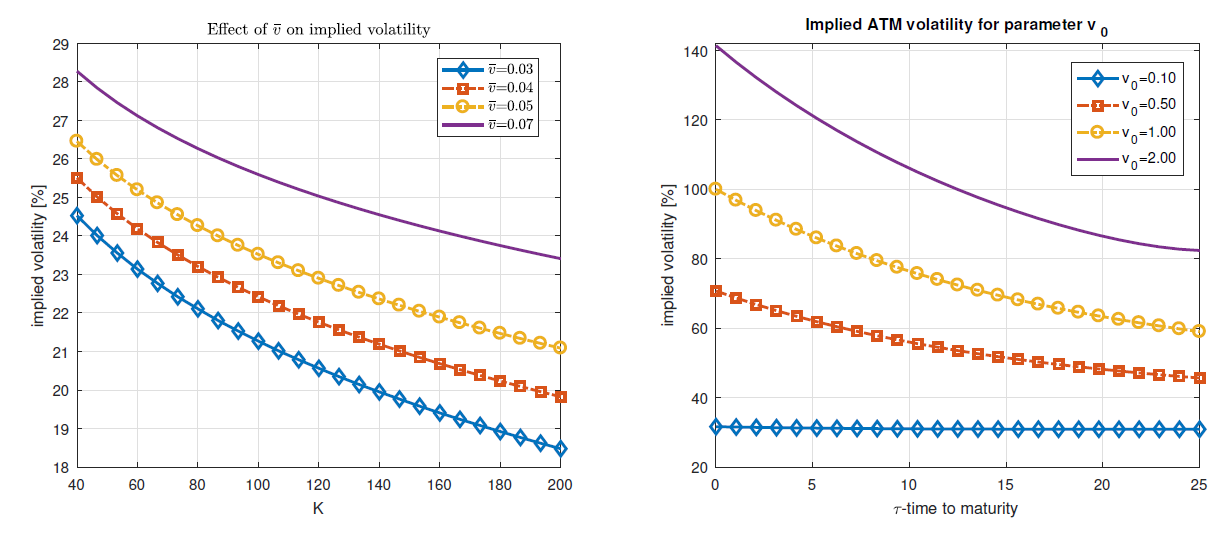<br>


## example finding Heston PDE

In [12]:
from sympy import symbols, expand, factor, diff, E, Function, maximum, Derivative, collect, simplify , Matrix, log, apart, Equality
import sympy
from sympy.abc import zeta
def ito_lemma_3D (
G = Function('G')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
    
X_1 = symbols('X_1'),
X_2 = symbols('X_2'),
X_3 = symbols('X_3'),
    
dW_1 = symbols('dW_1'),
dW_2 = symbols('dW_2'),
dW_3 = symbols('dW_3'),   
    
dB_1 = symbols('dB_1'),
dB_2 = symbols('dB_2'),
dB_3 = symbols('dB_3'),  
    
ρ_12 = symbols('ρ_12'),
ρ_13 = symbols('ρ_13'),
ρ_23 = symbols('ρ_23'), 
       
Θ_1 = Function('Θ_1')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Θ_2 = Function('Θ_2')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Θ_3 = Function('Θ_3')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),

Ψ_1 = Function('Ψ_1')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Ψ_2 = Function('Ψ_2')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),
Ψ_3 = Function('Ψ_3')(symbols('t'), symbols('X_1'), symbols('X_2'), symbols('X_3')),

factorize_it = False,
dependent_brownian = True
):


    dt, t = symbols(' dt,  t')

    Θ = Matrix([ 
          [Θ_1] ,
          [Θ_2] ,
          [Θ_3 ] 
    ])

    Ψ = Matrix([ 
          [ Ψ_1,  0      ,  0      ] ,
          [ 0      , Ψ_2 ,  0      ]  ,
          [ 0      ,   0     , Ψ_3 ] 
    ])

    dW = Matrix([ 
          [dW_1] ,
          [dW_2 ],  
          [dW_3 ]
    ])

    dB = Matrix([ 
          [dB_1] ,
          [dB_2 ] ,
          [dB_3 ]  
    ])

    C = Matrix([ 
          [1, ρ_12, ρ_13] ,
          [ρ_12, 1, ρ_23] ,
          [ρ_13 ,ρ_23, 1]
    ])

    L = C.cholesky(hermitian=False)
    Σ = Ψ*L
    
    print("The system of SDE is : ")
    if dependent_brownian :
        dX = Θ * dt + Ψ*dW
        display(dX)
        dX_1 = dX[0]
        dX_2 = dX[1]
        dX_3 = dX[2]
        
        
    else:
        dX = Θ * dt + Ψ*L*dB
        display(dX)
        dX_1 = dX[0]
        dX_2 = dX[1]
        dX_3 = dX[2]



    


    G_t = diff(G, t)

    G_x1 = diff(G, X_1) 
    G_x2 = diff(G, X_2) 
    G_x3 = diff(G, X_3) 

    G_x1_x1 = diff(G_x1, X_1) 
    G_x2_x2 = diff(G_x2, X_2)
    G_x3_x3 = diff(G_x3, X_3)

    G_x1_x2 = diff(G_x1, X_2) 
    G_x1_x3 = diff(G_x1, X_3) 

    G_x2_x1 = diff(G_x2, X_1) 
    G_x2_x3 = diff(G_x2, X_3) 

    G_x3_x1 = diff(G_x3, X_1) 
    G_x3_x2 = diff(G_x3, X_2) 


    dG = G_t *dt + G_x1 * dX_1  + G_x2 * dX_2 +  G_x3 * dX_3  +  1/2* (G_x1_x1 * dX_1 * dX_1 + 
                                                                   G_x2_x2 * dX_2 * dX_2 + 
                                                                   G_x3_x3 * dX_3 * dX_3 + 

                                                                   G_x1_x2 * dX_1 * dX_2 +
                                                                   G_x2_x1 * dX_2 * dX_1 +  

                                                                   G_x1_x3 * dX_1 * dX_3 +
                                                                   G_x3_x1 * dX_3 * dX_1 +

                                                                   G_x2_x3 * dX_2 * dX_3 +
                                                                   G_x3_x2 * dX_3 * dX_2                                                       
                                                                  )  

    dG = (
    expand (dG)
    .subs(dB_1**2, dt)
    .subs(dB_2**2, dt)
    .subs(dB_3**2, dt)
    .subs(dB_1*dt, 0)
    .subs(dB_2*dt, 0)
    .subs(dB_3*dt, 0)
    .subs(dB_1*dB_2, ρ_12*dt)
    .subs(dB_1*dB_3, ρ_13*dt)
    .subs(dB_2*dB_3, ρ_23*dt)
    .subs(dt**2,0)
    .subs(dW_1**2, dt)
    .subs(dW_2**2, dt)
    .subs(dW_3**2, dt)
    .subs(dW_1*dt, 0)
    .subs(dW_2*dt, 0)
    .subs(dW_3*dt, 0)
    .subs(dW_1*dW_2, ρ_12*dt)
    .subs(dW_1*dW_3, ρ_13*dt)
    .subs(dW_2*dW_3, ρ_23*dt)
    .subs(dt**2,0)
   .subs(G, symbols('G'))
    )
    
    return collect(dG , (dt,dB_1,dB_2, dB_3, dW_1,dW_2, dW_3, G ) )  if factorize_it else dG


In [15]:
dt, t, r = symbols('θ,  t, r')
κ, γ= symbols('κ, γ')
ζ =zeta

X_1 = S_t = symbols('S_t')
X_2 = v_t = symbols('v_t')
X_3 = M_t = symbols('M_t')

G = Function('V')(t, S_t, v_t) / M_t

dW_1 = symbols('dW_s')
dW_2 = symbols('dW_v')
dW_3 =  0

dB_1 = symbols('dB_s')
dB_2 = symbols('dB_v')
dB_3 = 0

ρ_12 = symbols('ρ')
ρ_13 = 0
ρ_23 = 0

Θ_1 = r * S_t
Θ_2 = κ * ( ζ - v_t)
Θ_3 = r * M_t

Ψ_1 = sympy.sqrt(v_t) * S_t
Ψ_2 = γ * sympy.sqrt(v_t) 
Ψ_3 = 0

dG = ito_lemma_3D ( G = G,
    
                    X_1 = X_1,
                    X_2 = X_2,
                    X_3 = X_3,
                    
                    dW_1 = dW_1,
                    dW_2 = dW_2,
                    dW_3 = dW_3,   
                    dB_1 = dB_1,
                    dB_2 = dB_2,
                    dB_3 = dB_3,  

                    ρ_12 = ρ_12,
                    ρ_13 = ρ_13,
                    ρ_23 = ρ_23, 

                    Θ_1 = Θ_1,
                    Θ_2 = Θ_2,
                    Θ_3 = Θ_3,

                    Ψ_1 = Ψ_1,
                    Ψ_2 = Ψ_2,
                    Ψ_3 = Ψ_3,

                    factorize_it = False, dependent_brownian=True
)

print(f"\n We have the dynamic of G follows")
simplify(dG*M_t)

The system of SDE is : 


Matrix([
[        S_t*dW_s*sqrt(v_t) + S_t*dt*r],
[dW_v*sqrt(v_t)*γ + dt*κ*(-v_t + zeta)],
[                             M_t*dt*r]])


 We have the dynamic of G follows


-G*M_t*dt*r + 0.5*S_t**2*dt*v_t*Derivative(V(t, S_t, v_t), (S_t, 2)) + S_t*dW_s*sqrt(v_t)*Derivative(V(t, S_t, v_t), S_t) + S_t*dt*r*Derivative(V(t, S_t, v_t), S_t) + 1.0*S_t*dt*v_t*γ*ρ*Derivative(V(t, S_t, v_t), S_t, v_t) + dW_v*sqrt(v_t)*γ*Derivative(V(t, S_t, v_t), v_t) + 0.5*dt*v_t*γ**2*Derivative(V(t, S_t, v_t), (v_t, 2)) - dt*v_t*κ*Derivative(V(t, S_t, v_t), v_t) + dt*zeta*κ*Derivative(V(t, S_t, v_t), v_t) + dt*Derivative(V(t, S_t, v_t), t)

## Option pricing under heston 

C:\Users\wb548956\AppData\Local\Temp/ipykernel_25080/511389856.py:106: DeprecationWarning: `np.complex` is a deprecated alias for the builtin `complex`. To silence this warning, use `complex` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.complex128` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  i = np.complex(0.0,1.0)
C:\Users\wb548956\AppData\Local\Temp/ipykernel_25080/511389856.py:26: DeprecationWarning: `np.complex` is a deprecated alias for the builtin `complex`. To silence this warning, use `complex` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.complex128` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  i = np.complex(0.0,1.0)


It took 2.980947494506836e-05 seconds to price.
Abs error for strike 80.0 is equal to 1.31E-07
Abs error for strike 90.0 is equal to 3.93E-07
Abs error for strike 100.0 is equal to 3.87E-07
Abs error for strike 110 is equal to 4.32E-07
Abs error for strike 120.0 is equal to 3.50E-07


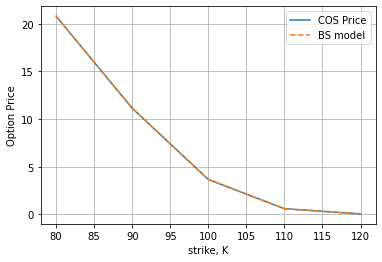

In [16]:
#%%
"""
Created on Thu Nov 27 2018
Pricing of European Call and Put options wit the COS method
@author: Lech A. Grzelak
"""
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import time

def CallPutOptionPriceCOSMthd(φ,CP,S0,r,τ,K,N,L):
    # φ   - characteristic function as a functon, in the book denoted as \varphi
    # CP   - C for call and P for put
    # S0   - Initial stock price
    # r    - interest rate (constant)
    # τ  - time to maturity
    # K    - list of strikes
    # N    - Number of expansion terms
    # L    - size of truncation domain (typ.:L=8 or L=10)  
        
    # reshape K to a column vector
    K = np.array(K).reshape([len(K),1])
    
    #assigning i=sqrt(-1)
    i = np.complex(0.0,1.0) 
    
    x0 = np.log(S0 / K)   
    
    # truncation domain
    a = 0.0 - L * np.sqrt(τ)
    b = 0.0 + L * np.sqrt(τ)
    
    # sumation from k = 0 to k=N-1
    k = np.linspace(0,N-1,N).reshape([N,1])  
    u = k * np.pi / (b - a);  

    # Determine coefficients for Put Prices  
    H_k = CallPutCoefficients(CP,a,b,k)
       
    mat = np.exp(i * np.outer((x0 - a) , u))

    temp = φ(u) * H_k 
    temp[0] = 0.5 * temp[0]    
    
    value = np.exp(-r * τ) * K * np.real(mat.dot(temp))
         
    return value

""" 
Determine coefficients for Put Prices 
"""
def CallPutCoefficients(CP,a,b,k):
    if str(CP).lower()=="c" or str(CP).lower()=="1":                  
        c = 0.0
        d = b
        coef = Chi_Psi(a,b,c,d,k)
        Chi_k = coef["chi"]
        Psi_k = coef["psi"]
        if a < b and b < 0.0:
            H_k = np.zeros([len(k),1])
        else:
            H_k      = 2.0 / (b - a) * (Chi_k - Psi_k)  
        
    elif str(CP).lower()=="p" or str(CP).lower()=="-1":
        c = a
        d = 0.0
        coef = Chi_Psi(a,b,c,d,k)
        Chi_k = coef["chi"]
        Psi_k = coef["psi"]
        H_k      = 2.0 / (b - a) * (- Chi_k + Psi_k)               
    
    return H_k    

def Chi_Psi(a,b,c,d,k):
    psi = np.sin(k * np.pi * (d - a) / (b - a)) - np.sin(k * np.pi * (c - a)/(b - a))
    psi[1:] = psi[1:] * (b - a) / (k[1:] * np.pi)
    psi[0] = d - c
    
    chi = 1.0 / (1.0 + np.power((k * np.pi / (b - a)) , 2.0)) 
    expr1 = np.cos(k * np.pi * (d - a)/(b - a)) * np.exp(d)  - np.cos(k * np.pi 
                  * (c - a) / (b - a)) * np.exp(c)
    expr2 = k * np.pi / (b - a) * np.sin(k * np.pi * 
                        (d - a) / (b - a))   - k * np.pi / (b - a) * np.sin(k 
                        * np.pi * (c - a) / (b - a)) * np.exp(c)
    chi = chi * (expr1 + expr2)
    
    value = {"chi":chi,"psi":psi }
    return value
    

def BS_Call_Option_Price(CP,S_0,K,sigma,tau,r):
    #Black-Scholes Call option price
    cp = str(CP).lower()
    K = np.array(K).reshape([len(K),1])
    d1    = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma,2.0)) 
    * tau) / float(sigma * np.sqrt(tau))
    d2    = d1 - sigma * np.sqrt(tau)
    if cp == "c" or cp == "1":
        value = st.norm.cdf(d1) * S_0 - st.norm.cdf(d2) * K * np.exp(-r * tau)
    elif cp == "p" or cp =="-1":
        value = st.norm.cdf(-d2) * K * np.exp(-r * tau) - st.norm.cdf(-d1)*S_0
    return value

def mainCalculation():
    i = np.complex(0.0,1.0)
    
    CP = "c"
    S0 = 100.0
    r = 0.1
    tau = 0.1
    sigma = 0.25
    K = [80.0, 90.0, 100.0, 110, 120.0]
    N = 4*32
    L = 10
    
    # Definition of the characteristic function for the GBM, this is an input
    # for the COS method
    # Note that Chf does not include coefficient "+iuX(t_0)" this coefficient
    # is included internally in the evaluation
    # In the book we denote this function as \varphi(u)

    cf = lambda u: np.exp((r - 0.5 * np.power(sigma,2.0)) * i * u * tau - 0.5 
                          * np.power(sigma, 2.0) * np.power(u, 2.0) * tau)
    
    # Timing results 
    NoOfIterations = 100
    time_start = time.time() 
    val_COS = CallPutOptionPriceCOSMthd(cf,CP,S0,r,tau,K,N,L)
    time_stop = time.time()
    print("It took {0} seconds to price.".format((time_stop-time_start)/float(NoOfIterations)))
    
    # evaluate analytical Black Scholes equation
    val_Exact = BS_Call_Option_Price(CP,S0,K,sigma,tau,r)
    plt.plot(K,val_COS)
    plt.plot(K,val_Exact,'--')
    plt.xlabel("strike, K")
    plt.ylabel("Option Price")
    plt.legend(["COS Price","BS model"])
    plt.grid()    
    
    #Error comuputation
    error = []
    for i in range(0,len(K)):
        error.append(np.abs(val_COS[i]-val_Exact[i])[0])
        print("Abs error for strike {0} is equal to {1:.2E}".format(K[i],error[i]))
        
mainCalculation()

# Bates model

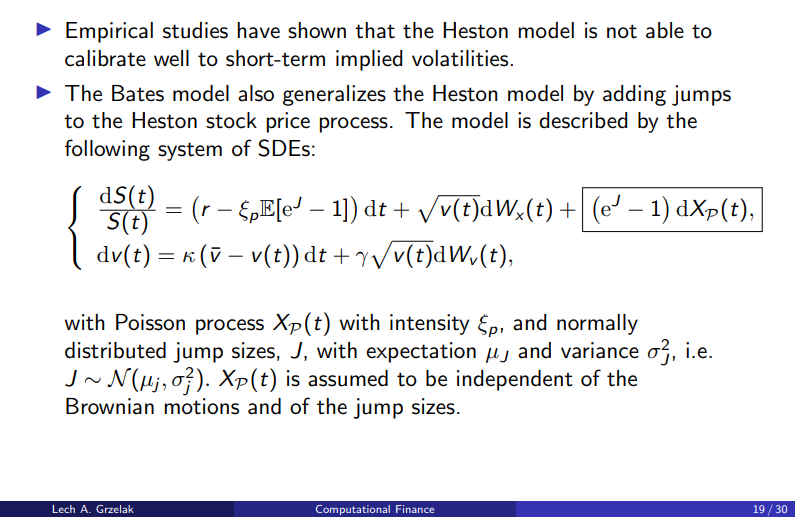 
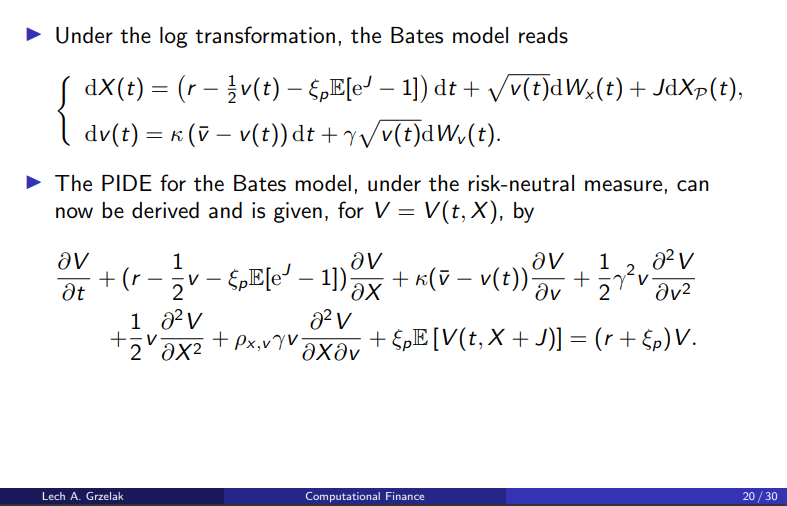
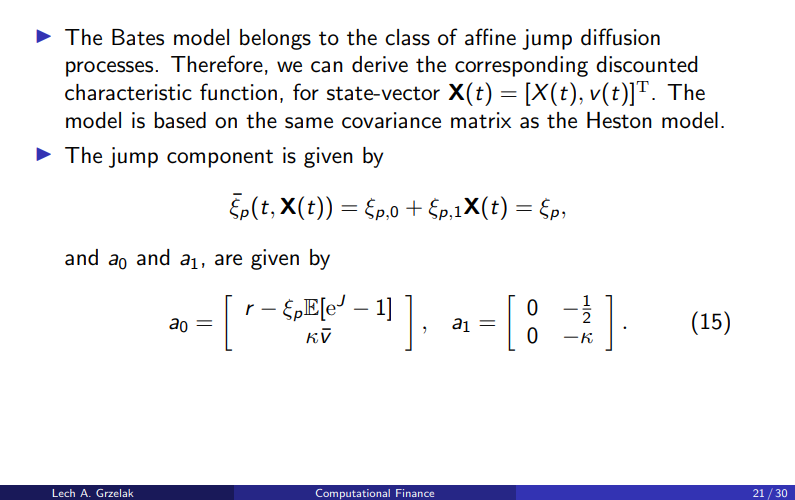
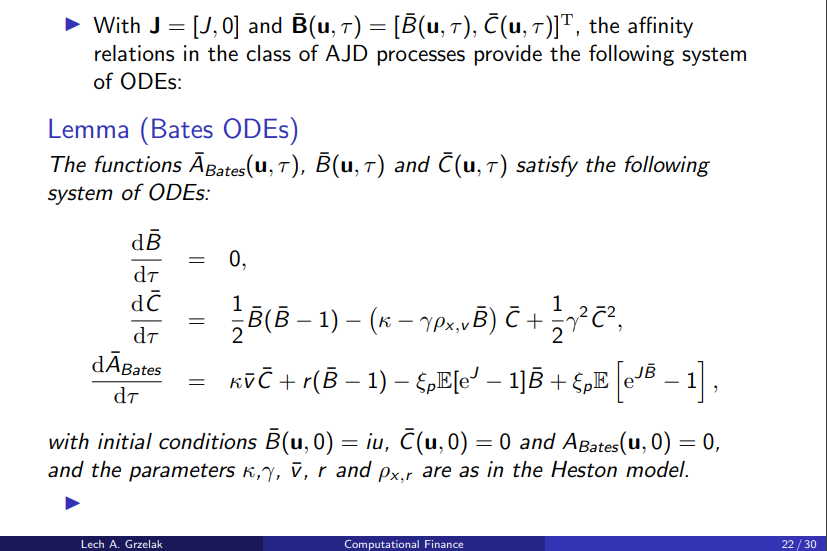
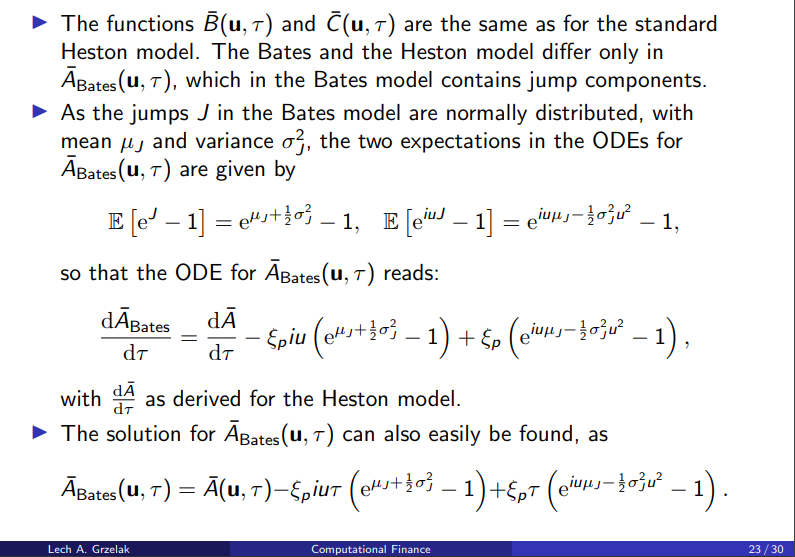
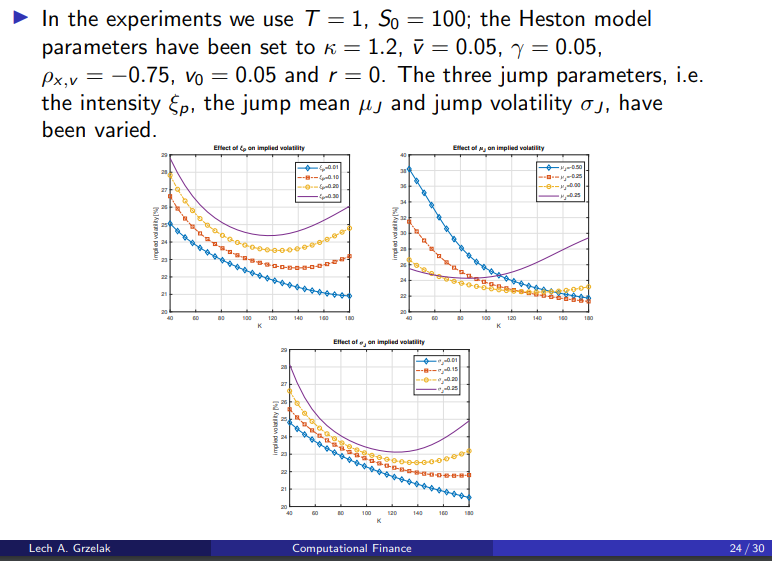
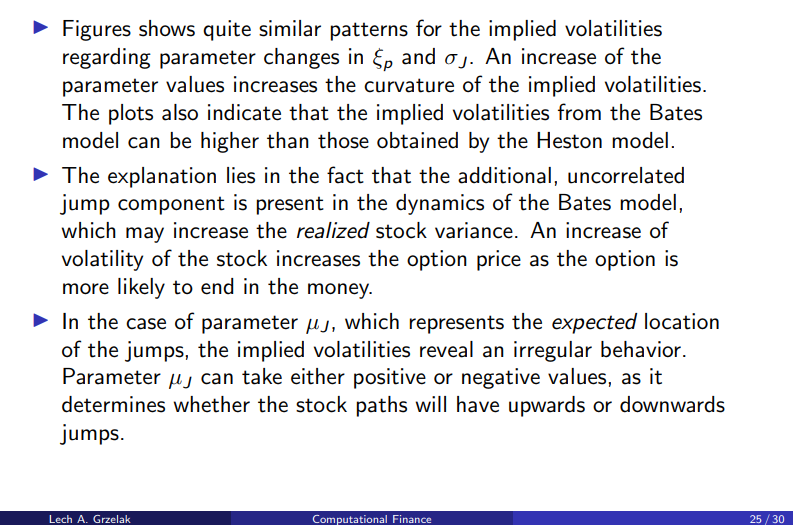